CROSS-SUBREDDIT COMPARISON: BURNOUT POST ENGAGEMENT
Loaded 12,237 bat_score>0 posts with subreddit info

DESCRIPTIVE: COMMENT VOLUME BY SUBREDDIT
                      n_posts  mean_comment_count  median_comment_count  \
subreddit                                                                 
sysadmin                 9871               27.17                   9.0   
ciso                       12               14.67                  13.5   
cybersecurity            1626               14.65                   6.0   
AskNetsec                 199                7.69                   5.0   
SecurityCareerAdvice      529                5.22                   3.0   

                      pct_zero_comments  
subreddit                                
sysadmin                           2.85  
ciso                               0.00  
cybersecurity                      6.52  
AskNetsec                          3.02  
SecurityCareerAdvice              11.15  

Mean comment score (posts with >=

/Users/nadia/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/nadia/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



✓ Figure saved: /Users/nadia/Desktop/redditRun_june/comment_data/subreddit_comparison.png

✓ subreddit_comparison_summary.csv saved  →  12,237 posts


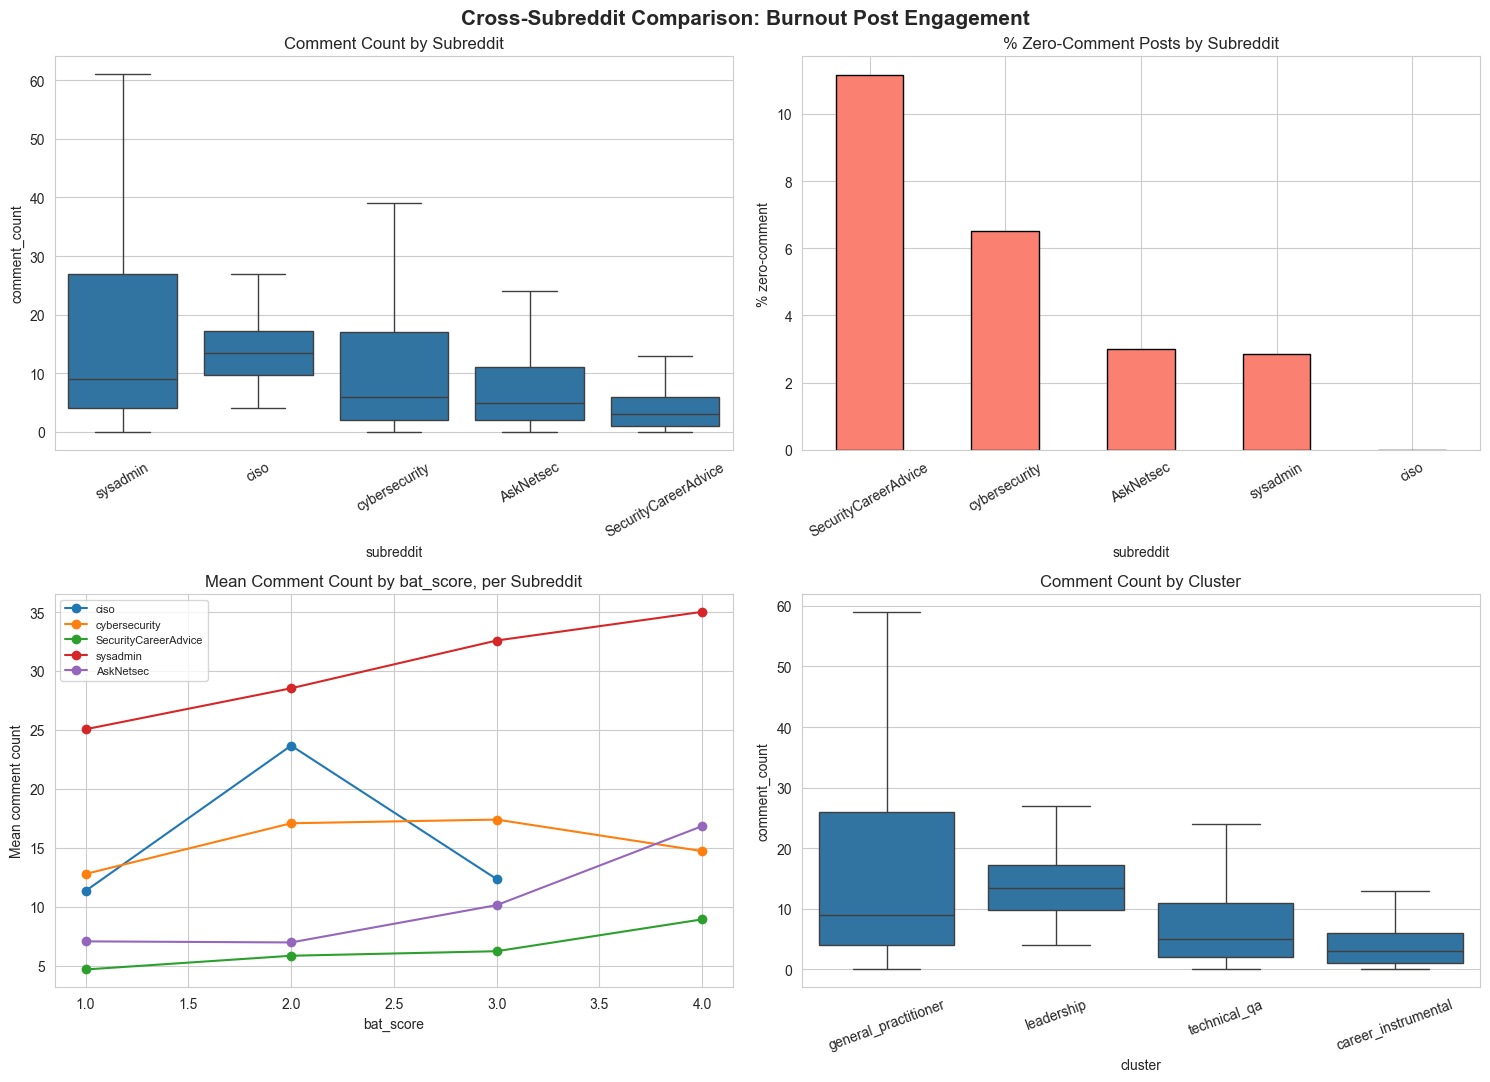

In [1]:
"""
CROSS-SUBREDDIT COMPARISON: COMMENT VOLUME/SCORE ON bat_score>0 POSTS
=========================================================================
Question: do different subreddit cultures respond differently to burnout
discourse? Two separate sub-questions:

  (a) DO SUBREDDITS DIFFER IN OVERALL ENGAGEMENT?
      e.g. does r/SecurityCareerAdvice just generally get more comments
      than r/ciso, regardless of bat_score?

  (b) DOES THE bat_score -> ENGAGEMENT RELATIONSHIP ITSELF DIFFER BY
      SUBREDDIT? (the more interesting question — an interaction effect)
      e.g. does severity predict more engagement in r/SecurityCareerAdvice
      (people jump in with career advice) but not in r/ciso (leadership
      venting gets acknowledged but not "solved")?

Clusters (as hypothesized — culturally distinct spaces):
    career_instrumental    = SecurityCareerAdvice
    general_practitioner    = cybersecurity, sysadmin
    leadership               = ciso
    technical_qa              = asknetsec   (not in the original 3-way
                                              split — added since it's
                                              in your data; drop/merge
                                              as you see fit)

Reads:
    volume_score_by_batscore_summary.csv   (post_id, bat_score, comment_count, mean_comment_score)
    bat_posts_results_with_dates_v2.csv     (post_id, subreddit)

Writes:
    subreddit_comparison_summary.csv
    subreddit_comparison.png
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'
VOLUME_FILE = DATA_DIR + 'volume_score_by_batscore_summary.csv'
BAT_DATES_FILE = DATA_DIR + 'bat_posts_results_with_dates_v2.csv'
OUTPUT_DIR = DATA_DIR

CLUSTER_MAP = {
    'SecurityCareerAdvice': 'career_instrumental',
    'cybersecurity': 'general_practitioner',
    'sysadmin': 'general_practitioner',
    'ciso': 'leadership',
    'AskNetsec': 'technical_qa',
}

sns.set_style("whitegrid")


def load_data():
    volume = pd.read_csv(VOLUME_FILE)
    volume['post_id'] = volume['post_id'].astype(str)

    bat = pd.read_csv(BAT_DATES_FILE, usecols=['post_id', 'subreddit'])
    bat['post_id'] = bat['post_id'].astype(str)

    df = volume.merge(bat, on='post_id', how='left')
    n_missing = df['subreddit'].isna().sum()
    if n_missing > 0:
        print(f"⚠ {n_missing:,} posts missing subreddit after merge — dropping")
        df = df.dropna(subset=['subreddit'])

    df['cluster'] = df['subreddit'].map(CLUSTER_MAP)
    unmapped = df[df['cluster'].isna()]['subreddit'].unique()
    if len(unmapped) > 0:
        print(f"⚠ Unmapped subreddits found (add to CLUSTER_MAP if needed): {unmapped}")

    print(f"Loaded {len(df):,} bat_score>0 posts with subreddit info")
    return df


def descriptive_by_subreddit(df):
    print("\n" + "=" * 70)
    print("DESCRIPTIVE: COMMENT VOLUME BY SUBREDDIT")
    print("=" * 70)
    summary = df.groupby('subreddit').agg(
        n_posts=('post_id', 'count'),
        mean_comment_count=('comment_count', 'mean'),
        median_comment_count=('comment_count', 'median'),
        pct_zero_comments=('comment_count', lambda x: (x == 0).mean() * 100),
    ).round(2)
    print(summary.sort_values('mean_comment_count', ascending=False))

    with_comments = df[df['comment_count'] > 0]
    print("\nMean comment score (posts with >=1 comment) by subreddit:")
    print(with_comments.groupby('subreddit')['mean_comment_score'].agg(['count', 'mean', 'median']).round(2))

    print("\n" + "=" * 70)
    print("DESCRIPTIVE: BY CLUSTER (career_instrumental / general_practitioner / leadership / technical_qa)")
    print("=" * 70)
    cluster_summary = df.groupby('cluster').agg(
        n_posts=('post_id', 'count'),
        mean_comment_count=('comment_count', 'mean'),
        median_comment_count=('comment_count', 'median'),
        pct_zero_comments=('comment_count', lambda x: (x == 0).mean() * 100),
    ).round(2)
    print(cluster_summary.sort_values('mean_comment_count', ascending=False))

    return summary, cluster_summary, with_comments


def significance_tests(df, with_comments):
    print("\n" + "─" * 70)
    print("SIGNIFICANCE TESTS")
    print("─" * 70)

    # (a) Do subreddits differ in overall volume?
    groups = [df.loc[df['subreddit'] == s, 'comment_count'] for s in df['subreddit'].unique()]
    h, p = stats.kruskal(*groups)
    print(f"\nKruskal-Wallis (comment_count across 5 subreddits): H={h:.3f}, p={p:.4g}")

    groups_cl = [df.loc[df['cluster'] == c, 'comment_count'] for c in df['cluster'].dropna().unique()]
    h_cl, p_cl = stats.kruskal(*groups_cl)
    print(f"Kruskal-Wallis (comment_count across 4 clusters): H={h_cl:.3f}, p={p_cl:.4g}")

    # Zero-comment rate: chi-square across subreddits
    df['has_zero'] = (df['comment_count'] == 0).astype(int)
    contingency = pd.crosstab(df['subreddit'], df['has_zero'])
    chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
    print(f"\nChi-square (zero-comment rate across subreddits): chi2={chi2:.3f}, p={p_chi2:.4g}")

    # Comment score across subreddits (posts with >=1 comment)
    groups_score = [with_comments.loc[with_comments['subreddit'] == s, 'mean_comment_score']
                     for s in with_comments['subreddit'].unique()]
    h_s, p_s = stats.kruskal(*groups_score)
    print(f"\nKruskal-Wallis (mean_comment_score across subreddits): H={h_s:.3f}, p={p_s:.4g}")


def interaction_model(df):
    print("\n" + "─" * 70)
    print("DOES THE bat_score -> ENGAGEMENT RELATIONSHIP DIFFER BY SUBREDDIT?")
    print("(NB regression with bat_score x subreddit interaction)")
    print("─" * 70)

    # Main-effects-only model
    main = smf.glm('comment_count ~ bat_score + C(subreddit)', data=df,
                    family=sm.families.NegativeBinomial()).fit()

    # Interaction model
    interaction = smf.glm('comment_count ~ bat_score * C(subreddit)', data=df,
                           family=sm.families.NegativeBinomial()).fit()

    print(f"\nMain-effects model:  AIC={main.aic:.1f}  BIC={main.bic:.1f}")
    print(f"Interaction model:   AIC={interaction.aic:.1f}  BIC={interaction.bic:.1f}")

    # Likelihood ratio test: does adding the interaction significantly improve fit?
    lr_stat = 2 * (interaction.llf - main.llf)
    df_diff = interaction.df_model - main.df_model
    lr_p = stats.chi2.sf(lr_stat, df_diff)
    print(f"\nLikelihood ratio test (interaction vs main-effects only): "
          f"LR={lr_stat:.3f}, df={df_diff:.0f}, p={lr_p:.4g}")

    if lr_p < 0.05:
        print("→ Significant: the bat_score-engagement relationship DIFFERS by subreddit.")
    else:
        print("→ Not significant: no strong evidence the bat_score-engagement slope "
              "differs across subreddits (a single overall slope fits about as well).")

    print("\nFull interaction model summary:")
    print(interaction.summary())

    return main, interaction


def make_figure(df, with_comments):
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Cross-Subreddit Comparison: Burnout Post Engagement', fontsize=15, fontweight='bold')

    order = df.groupby('subreddit')['comment_count'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x='subreddit', y='comment_count', order=order, ax=axes[0, 0], showfliers=False)
    axes[0, 0].set_title('Comment Count by Subreddit')
    axes[0, 0].tick_params(axis='x', rotation=30)

    zero_rates = df.groupby('subreddit')['comment_count'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)
    zero_rates.plot(kind='bar', ax=axes[0, 1], color='salmon', edgecolor='black')
    axes[0, 1].set_title('% Zero-Comment Posts by Subreddit')
    axes[0, 1].set_ylabel('% zero-comment')
    axes[0, 1].tick_params(axis='x', rotation=30)

    for sub in df['subreddit'].unique():
        sub_data = df[df['subreddit'] == sub].groupby('bat_score')['comment_count'].mean()
        axes[1, 0].plot(sub_data.index, sub_data.values, marker='o', label=sub)
    axes[1, 0].set_title('Mean Comment Count by bat_score, per Subreddit')
    axes[1, 0].set_xlabel('bat_score')
    axes[1, 0].set_ylabel('Mean comment count')
    axes[1, 0].legend(fontsize=8)

    cluster_order = df.groupby('cluster')['comment_count'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x='cluster', y='comment_count', order=cluster_order, ax=axes[1, 1], showfliers=False)
    axes[1, 1].set_title('Comment Count by Cluster')
    axes[1, 1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    out_path = OUTPUT_DIR + 'subreddit_comparison.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Figure saved: {out_path}")


if __name__ == '__main__':
    print("=" * 80)
    print("CROSS-SUBREDDIT COMPARISON: BURNOUT POST ENGAGEMENT")
    print("=" * 80)

    df = load_data()
    summary, cluster_summary, with_comments = descriptive_by_subreddit(df)
    significance_tests(df, with_comments)
    main_model, interaction_model_fit = interaction_model(df)
    make_figure(df, with_comments)

    df.to_csv(OUTPUT_DIR + 'subreddit_comparison_summary.csv', index=False)
    print(f"\n✓ subreddit_comparison_summary.csv saved  →  {len(df):,} posts")